In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import sys
from pathlib import Path
import configparser

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

config = configparser.ConfigParser()
config.read(PROJECT_ROOT / "config.ini", encoding="utf-8")
TRAIN_FILE = PROJECT_ROOT / config.get("PATHS", "TRAIN_FILE")

In [5]:
df_sales = pd.read_csv(TRAIN_FILE)
df_sales['Date'] = pd.to_datetime(df_sales['Date'])

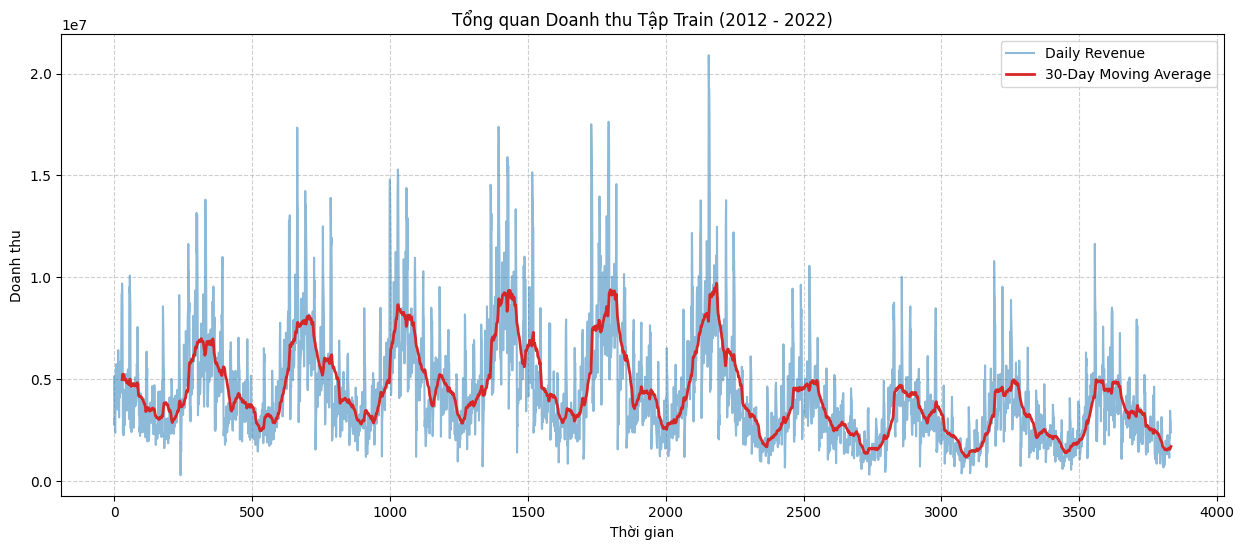

In [6]:
# Vẽ biểu đồ Doanh thu hàng ngày và Trung bình động 30 ngày
plt.figure(figsize=(15, 6))
plt.plot(df_sales.index, df_sales['Revenue'], label='Daily Revenue', color='#1f77b4', alpha=0.5)
plt.plot(df_sales.index, df_sales['Revenue'].rolling(window=30).mean(), 
         label='30-Day Moving Average', color='#d62728', linewidth=2)
plt.title('Tổng quan Doanh thu Tập Train (2012 - 2022)')
plt.xlabel('Thời gian')
plt.ylabel('Doanh thu')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

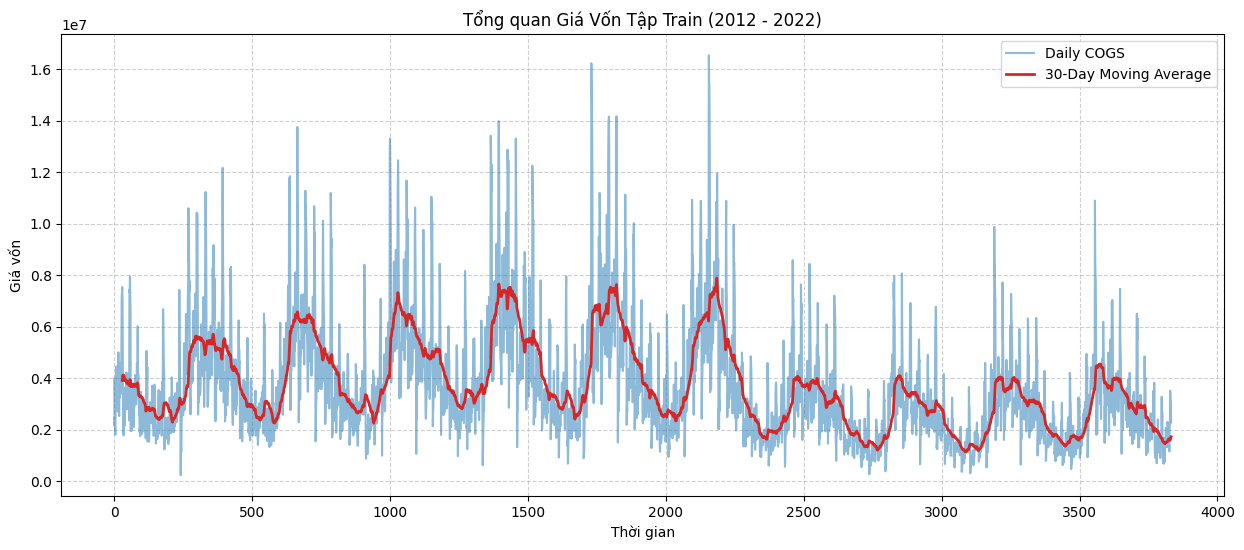

In [7]:
# Vẽ biểu đồ Doanh thu hàng ngày và Trung bình động 30 ngày
plt.figure(figsize=(15, 6))
plt.plot(df_sales.index, df_sales['COGS'], label='Daily COGS', color='#1f77b4', alpha=0.5)
plt.plot(df_sales.index, df_sales['COGS'].rolling(window=30).mean(), 
         label='30-Day Moving Average', color='#d62728', linewidth=2)
plt.title('Tổng quan Giá Vốn Tập Train (2012 - 2022)')
plt.xlabel('Thời gian')
plt.ylabel('Giá vốn')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

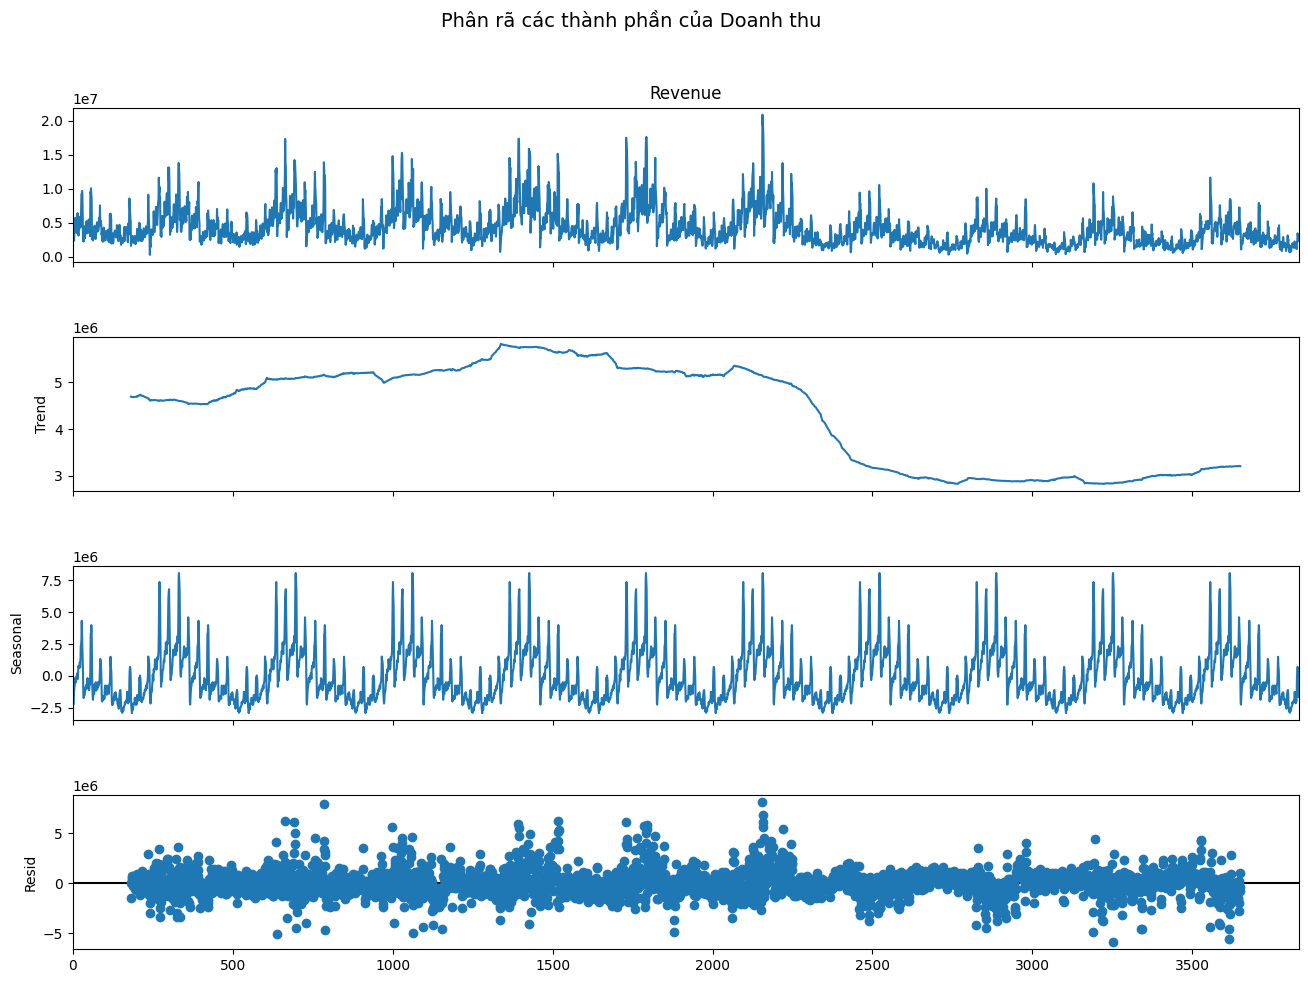

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Thực hiện phân rã chuỗi thời gian (giả định chu kỳ năm: period=365)
# Nếu muốn xem chu kỳ tuần, bạn có thể đổi period=7
decomposition = seasonal_decompose(df_sales['Revenue'].dropna(), model='additive', period=365)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
fig.suptitle('Phân rã các thành phần của Doanh thu', fontsize=14, y=1.02)
plt.show()

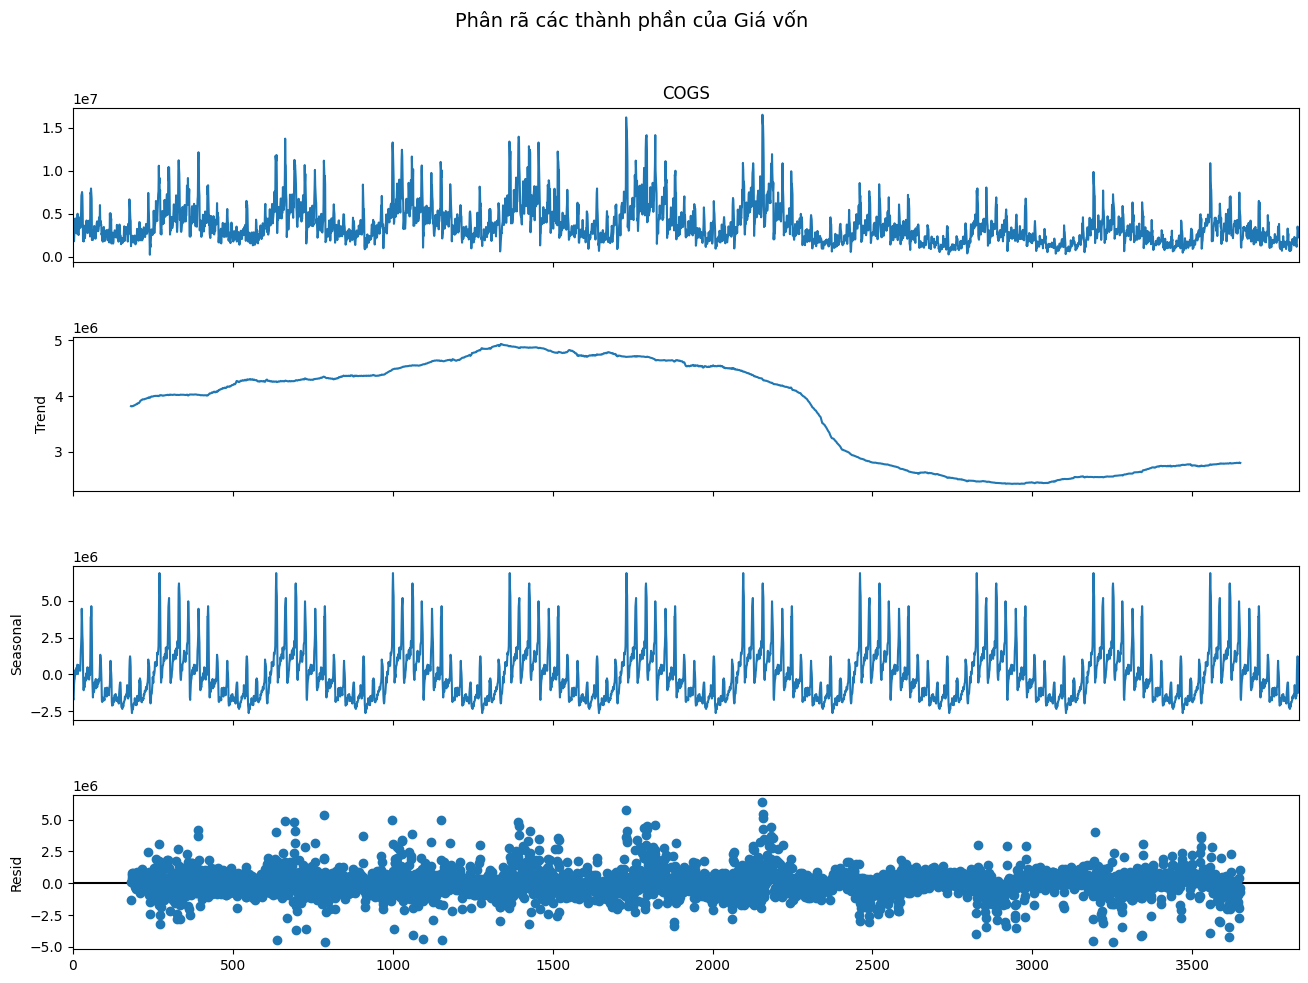

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Thực hiện phân rã chuỗi thời gian (giả định chu kỳ năm: period=365)
# Nếu muốn xem chu kỳ tuần, bạn có thể đổi period=7
decomposition = seasonal_decompose(df_sales['COGS'].dropna(), model='additive', period=365)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
fig.suptitle('Phân rã các thành phần của Giá vốn', fontsize=14, y=1.02)
plt.show()

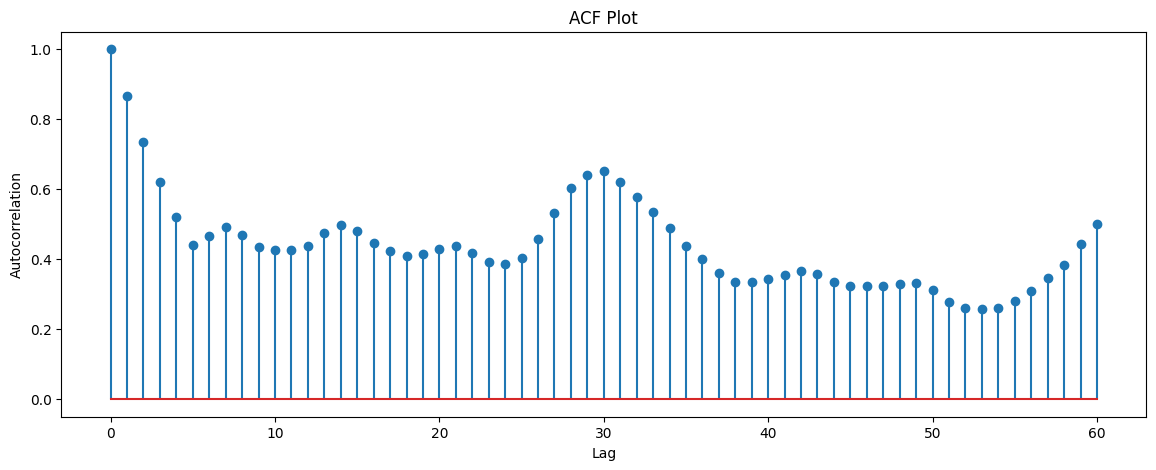

In [10]:
series = df_sales['Revenue'].dropna()

lags = 60
acf = [series.autocorr(lag=i) for i in range(lags + 1)]

plt.figure(figsize=(14,5))

plt.stem(range(lags + 1), acf)

plt.title('ACF Plot')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')

plt.show()

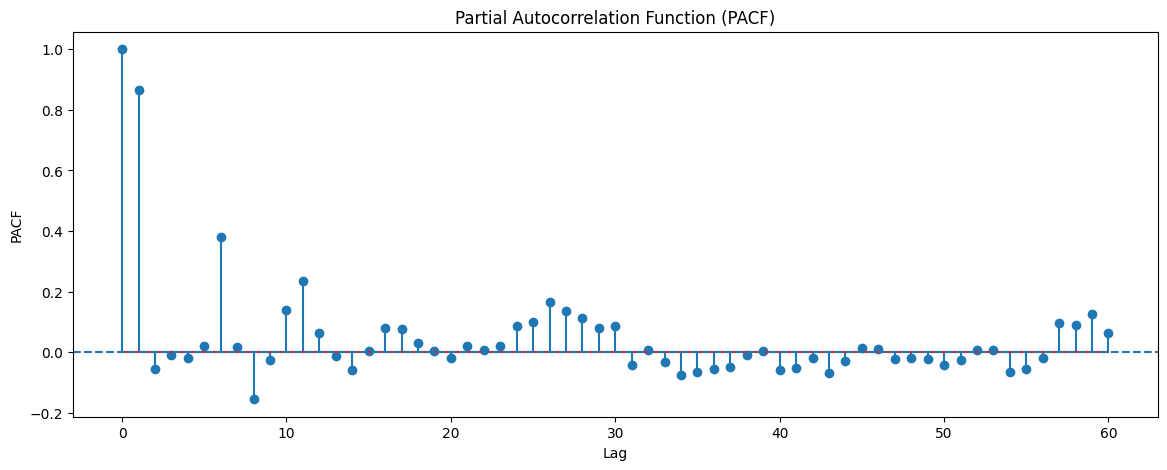

In [11]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import pacf

# Chuẩn bị dữ liệu
series = df_sales['Revenue'].dropna()

# Tính PACF
pacf_values = pacf(series, nlags=60)

# Vẽ
plt.figure(figsize=(14, 5))

plt.stem(range(len(pacf_values)), pacf_values)

plt.title('Partial Autocorrelation Function (PACF)')
plt.xlabel('Lag')
plt.ylabel('PACF')

plt.axhline(0, linestyle='--')

plt.show()

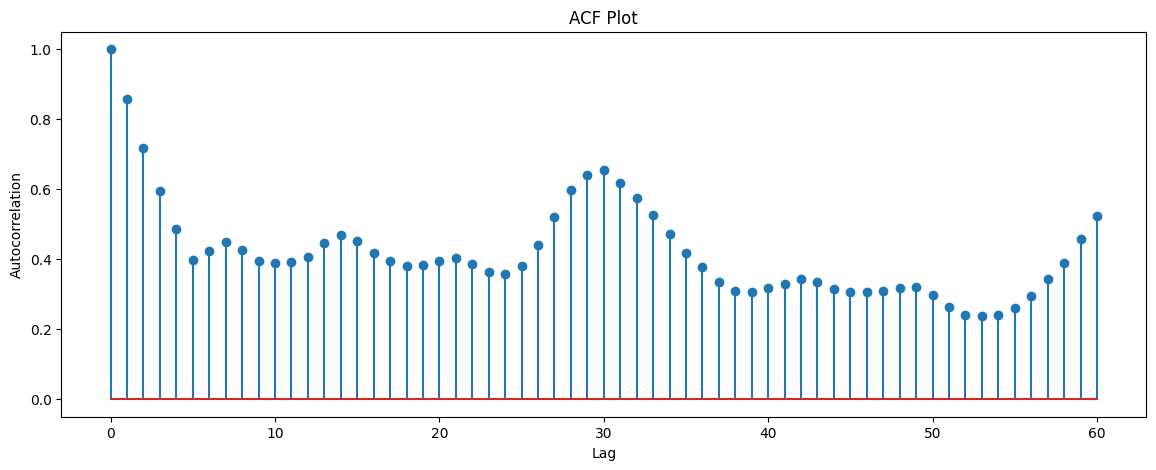

In [12]:
series = df_sales['COGS'].dropna()

lags = 60
acf = [series.autocorr(lag=i) for i in range(lags + 1)]

plt.figure(figsize=(14,5))

plt.stem(range(lags + 1), acf)

plt.title('ACF Plot')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')

plt.show()

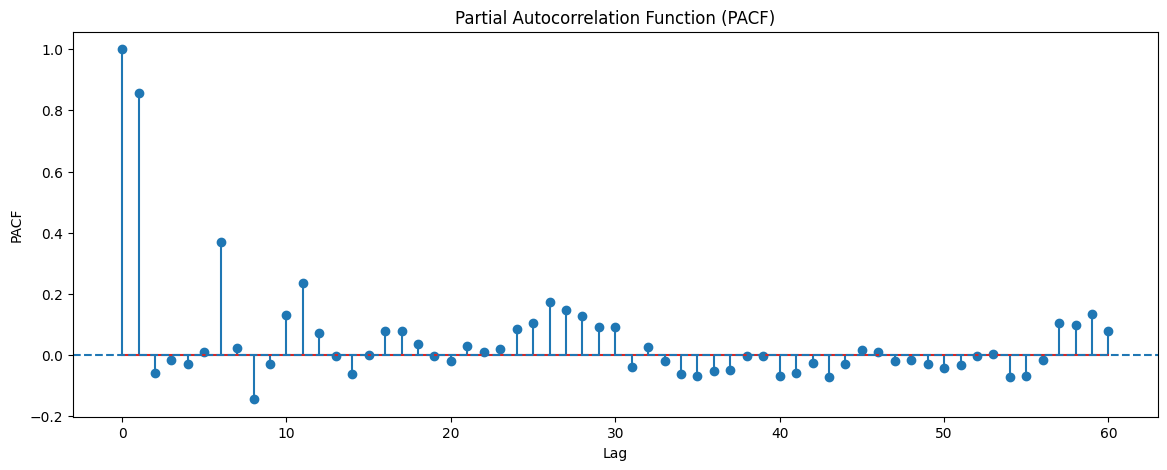

In [13]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import pacf

# Chuẩn bị dữ liệu
series = df_sales['COGS'].dropna()

# Tính PACF
pacf_values = pacf(series, nlags=60)

# Vẽ
plt.figure(figsize=(14, 5))

plt.stem(range(len(pacf_values)), pacf_values)

plt.title('Partial Autocorrelation Function (PACF)')
plt.xlabel('Lag')
plt.ylabel('PACF')

plt.axhline(0, linestyle='--')

plt.show()

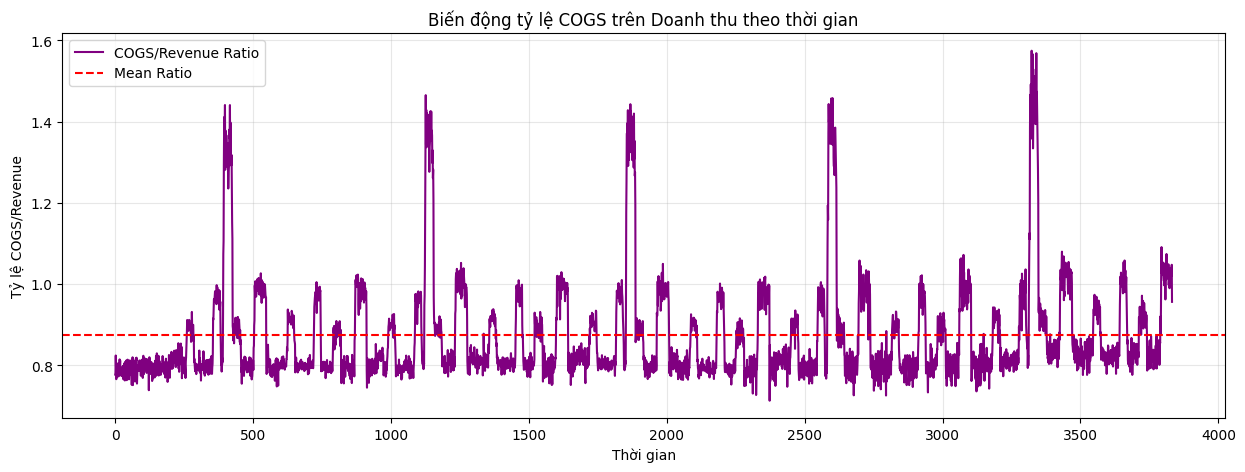

In [14]:
# Tính toán tỷ lệ
# Lưu ý: Nên xử lý trường hợp Revenue = 0 để tránh lỗi vô cực (inf)
temp = df_sales['COGS'] / df_sales['Revenue']

plt.figure(figsize=(15, 5))

# Thay df_sales['Date'] bằng df_sales.index
plt.plot(df_sales.index, temp, color='purple', label='COGS/Revenue Ratio')

# Lưu ý: dùng temp.mean() vì bạn chưa gán ngược temp vào df_sales['cogs_ratio']
plt.axhline(y=temp.mean(), color='r', linestyle='--', label='Mean Ratio')

plt.title('Biến động tỷ lệ COGS trên Doanh thu theo thời gian')
plt.xlabel('Thời gian')
plt.ylabel('Tỷ lệ COGS/Revenue')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Đường trung bình (Mean Ratio) nằm ở mức ~0.87, nghĩa là thông thường giá vốn chiếm khoảng 87% doanh thu (biên lợi nhuận gộp khoảng 13%).

Điểm bất thường: Định kỳ hàng năm, có những thời điểm tỷ lệ này vọt lên vượt mức 1.0 (thậm chí chạm 1.4 - 1.6). Khi COGS/Revenue > 1, nghĩa là công ty đang bán lỗ (Giá vốn > Doanh thu).

Ý nghĩa kinh doanh (Diagnostic/Prescriptive): Tại sao công ty thời trang lại bán lỗ định kỳ? Đây chắc chắn là các đợt "Xả kho" (Clearance Sale), các sự kiện siêu sale như Black Friday, hoặc xả hàng cuối mùa để thu hồi vốn và giải phóng hàng tồn kho (liên kết với bảng inventory.csv). Việc hy sinh lợi nhuận gộp ngắn hạn để đổi lấy dòng tiền và giảm chi phí lưu kho là một chiến lược phổ biến.

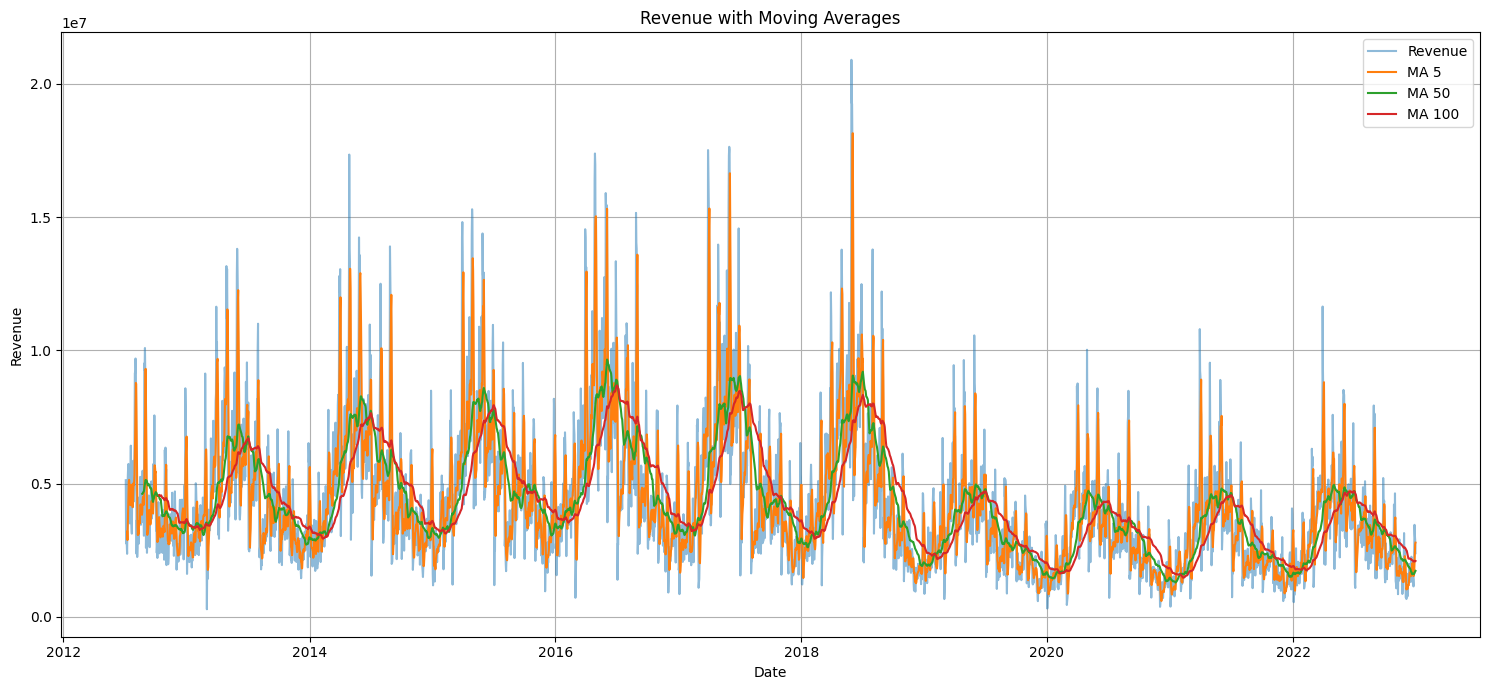

In [15]:
ts = df_sales['Revenue']

ma_5 = ts.rolling(window=5).mean()
ma_50 = ts.rolling(window=50).mean()
ma_100 = ts.rolling(window=100).mean()

plt.figure(figsize=(15, 7))

# Revenue gốc
plt.plot(
    df_sales['Date'],
    ts,
    label='Revenue',
    alpha=0.5
)

# Moving averages
plt.plot(
    df_sales['Date'],
    ma_5,
    label='MA 5'
)

plt.plot(
    df_sales['Date'],
    ma_50,
    label='MA 50'
)

plt.plot(
    df_sales['Date'],
    ma_100,
    label='MA 100'
)

plt.title('Revenue with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Revenue')

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

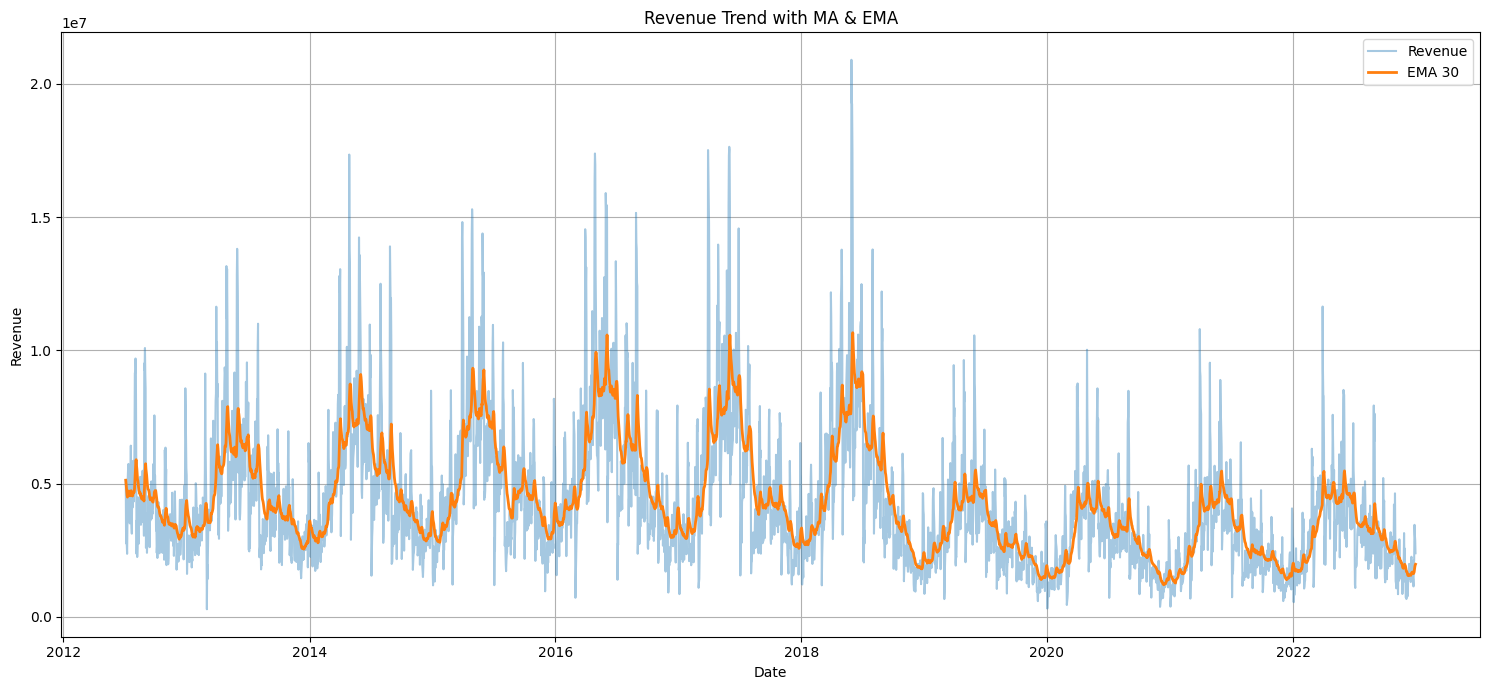

In [16]:
ts_ema = ts.ewm(span = 30, adjust = False).mean()

# Plot
plt.figure(figsize=(15, 7))

# Original series
plt.plot(
    df_sales['Date'],
    ts,
    label='Revenue',
    alpha=0.4
)
# EMA
plt.plot(
    df_sales['Date'],
    ts_ema,
    label='EMA 30',
    linewidth=2
)

# Decorations
plt.title('Revenue Trend with MA & EMA')
plt.xlabel('Date')
plt.ylabel('Revenue')

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [17]:
from statsmodels.tsa.stattools import adfuller

df_sales['Revenue_diff_1'] = df_sales['Revenue'].diff()

def check_stationarity(series):
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("=> Dữ liệu có tính dừng (Stationary)")
    else:
        print("=> Dữ liệu KHÔNG có tính dừng (Non-Stationary)")

# Chạy thử trên doanh thu gốc và doanh thu đã lấy sai phân bậc 1
check_stationarity(df_sales['Revenue'])
check_stationarity(df_sales['Revenue_diff_1'])

ADF Statistic: -2.5250
p-value: 0.1095
=> Dữ liệu KHÔNG có tính dừng (Non-Stationary)
ADF Statistic: -23.5321
p-value: 0.0000
=> Dữ liệu có tính dừng (Stationary)
